- State: `(player_sum, dealer_showing, usable_ace)`
- Actions: `0 = stick`, `1 = hit`
- Reward: +1 win / 0 draw / −1 loss (terminal only), γ = 1.0

In [2]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import defaultdict

np.random.seed(0)
N_EPISODES = 500_000   # required 
GAMMA = 1.0

## (c) First-visit MC prediction for the fixed policy
**Policy:** stick if player_sum ≥ 20, otherwise hit.

In [8]:
def fixed_policy(state):
    player_sum, dealer, usable = state
    return 0 if player_sum >= 20 else 1   # 0 = stick, 1 = hit

def generate_episode(env, policy):
    """Roll out one episode; return list of (state, action, reward)."""
    episode = []
    state, _ = env.reset()
    done = False
    while not done:
        action = policy(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode.append((state, action, reward))
        state = next_state
    return episode

def mc_prediction(env, policy, n_episodes, gamma=1.0):
    """First-visit MC prediction (alpha = 1/N). slide 9/Lesson 6A"""
    V = defaultdict(float)
    N = defaultdict(int)
    for ep in range(n_episodes):
        episode = generate_episode(env, policy)
        returns = [0.0] * len(episode)
        g = 0.0
        for i in reversed(range(len(episode))):
            g = episode[i][2] + gamma * g # G_t calc as in psuedo code, (gamma = 1)
            returns[i] = g
        first_idx = {}
        for i, (s, a, r) in enumerate(episode):
            first_idx.setdefault(s, i)
        for s, i in first_idx.items():
            N[s] += 1
            V[s] += (returns[i] - V[s]) / N[s] # calc avg
    return V

env = gym.make("Blackjack-v1")
V = mc_prediction(env, fixed_policy, N_EPISODES, GAMMA)
print("States estimated:", len(V))

States estimated: 280


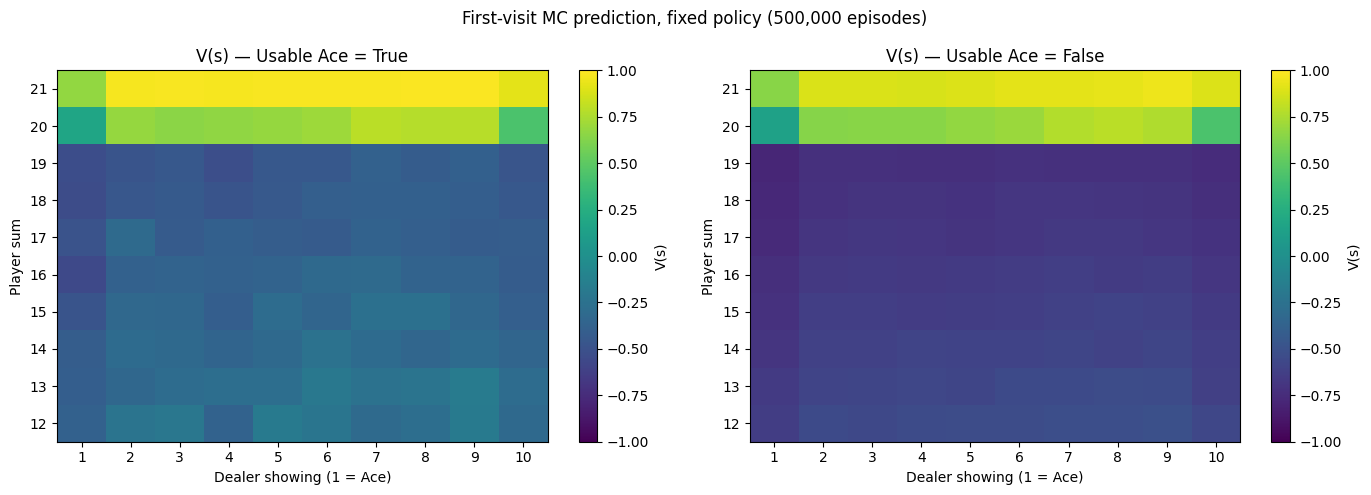

In [9]:
def value_grid(V, usable_ace):
    """(player_sum 12..21) x (dealer 1..10) grid of state values."""
    player_sums = range(12, 22)   # below 12 the policy always hits
    dealers = range(1, 11)
    grid = np.zeros((len(player_sums), len(dealers)))
    for i, ps in enumerate(player_sums):
        for j, d in enumerate(dealers):
            grid[i, j] = V.get((ps, d, usable_ace), 0.0)
    return grid, list(player_sums), list(dealers)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, usable, title in [(axes[0], True, "Usable Ace = True"),
                          (axes[1], False, "Usable Ace = False")]:
    grid, psums, dealers = value_grid(V, usable)
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis",
                   vmin=-1, vmax=1,
                   extent=[dealers[0]-0.5, dealers[-1]+0.5, psums[0]-0.5, psums[-1]+0.5])
    ax.set_title(f"V(s) — {title}")
    ax.set_xlabel("Dealer showing (1 = Ace)")
    ax.set_ylabel("Player sum")
    ax.set_xticks(dealers)
    ax.set_yticks(psums)
    fig.colorbar(im, ax=ax, label="V(s)")
fig.suptitle(f"First-visit MC prediction, fixed policy ({N_EPISODES:,} episodes)")
plt.tight_layout()
plt.savefig("mc_prediction_value.png", dpi=120, bbox_inches="tight")
plt.show()

## (d) MC control with an ε-soft policy (ε = 0.1) to estimate q*

In [10]:
def mc_control_epsilon_soft(env, n_episodes, epsilon=0.1, gamma=1.0):
    """First-visit MC control with an epsilon-soft behavior policy d"""
    nA = env.action_space.n
    Q = defaultdict(lambda: np.zeros(nA))
    N = defaultdict(lambda: np.zeros(nA))
    for ep in range(n_episodes):
        episode = []
        state, _ = env.reset()
        done = False
        while not done:
            if np.random.rand() < epsilon:
                action = np.random.randint(nA)          # explore
            else:
                action = int(np.argmax(Q[state]))       # exploit
            ns, r, term, trunc, _ = env.step(action)
            done = term or trunc
            episode.append((state, action, r))
            state = ns
        # --- first-visit returns ---
        returns = [0.0] * len(episode)
        g = 0.0
        for i in reversed(range(len(episode))):
            g = episode[i][2] + gamma * g
            returns[i] = g
        seen = set()
        for i, (s, a, r) in enumerate(episode):
            if (s, a) not in seen:
                seen.add((s, a))
                N[s][a] += 1
                Q[s][a] += (returns[i] - Q[s][a]) / N[s][a]
    return Q

env = gym.make("Blackjack-v1")
Q = mc_control_epsilon_soft(env, N_EPISODES, epsilon=0.1, gamma=GAMMA)
print("State-action pairs estimated:", sum(len(v) for v in [Q]))
print("Distinct states in Q:", len(Q))

State-action pairs estimated: 280
Distinct states in Q: 280


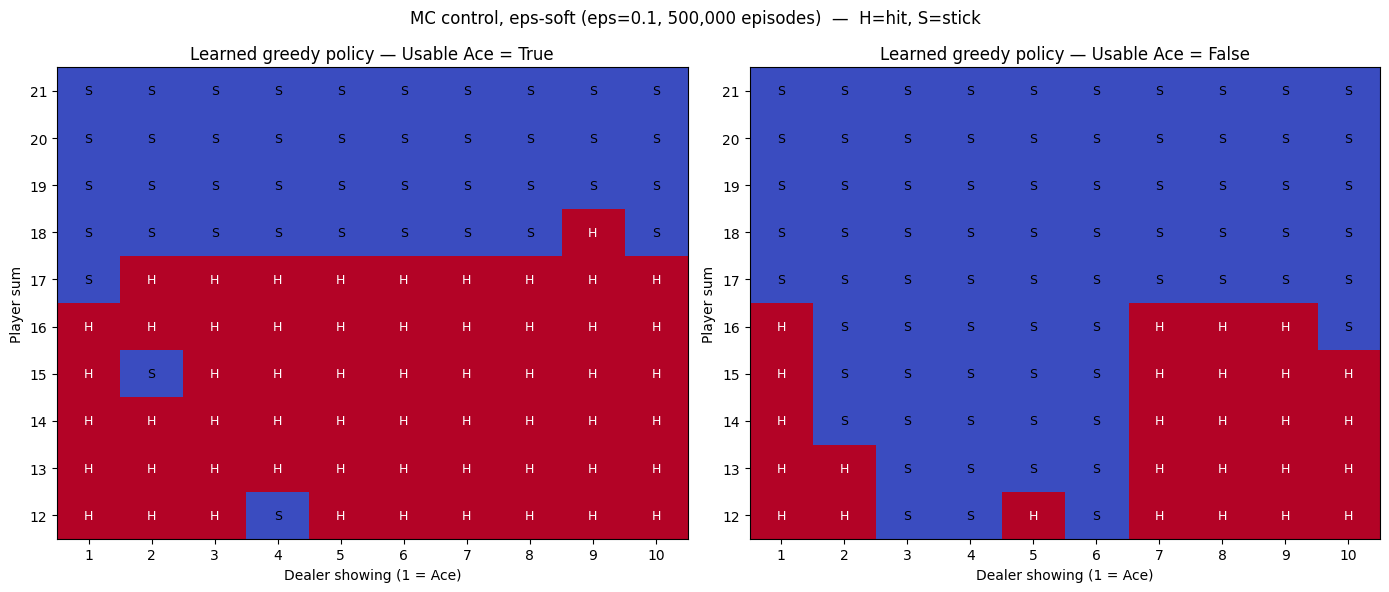

In [6]:
def policy_grid(Q, usable_ace):
    """Greedy action (0=stick,1=hit) for each (player_sum, dealer)."""
    player_sums = range(12, 22)
    dealers = range(1, 11)
    grid = np.zeros((len(player_sums), len(dealers)))
    for i, ps in enumerate(player_sums):
        for j, d in enumerate(dealers):
            grid[i, j] = int(np.argmax(Q[(ps, d, usable_ace)]))  # 1 = hit
    return grid, list(player_sums), list(dealers)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, usable, title in [(axes[0], True, "Usable Ace = True"),
                          (axes[1], False, "Usable Ace = False")]:
    grid, psums, dealers = policy_grid(Q, usable)
    ax.imshow(grid, origin="lower", aspect="auto", cmap="coolwarm",
              extent=[dealers[0]-0.5, dealers[-1]+0.5, psums[0]-0.5, psums[-1]+0.5])
    for i, ps in enumerate(psums):
        for j, d in enumerate(dealers):
            ax.text(d, ps, "H" if grid[i, j] == 1 else "S",
                    ha="center", va="center", fontsize=9,
                    color="white" if grid[i, j] == 1 else "black")
    ax.set_title(f"Learned greedy policy — {title}")
    ax.set_xlabel("Dealer showing (1 = Ace)")
    ax.set_ylabel("Player sum")
    ax.set_xticks(dealers)
    ax.set_yticks(psums)
fig.suptitle(f"MC control, eps-soft (eps=0.1, {N_EPISODES:,} episodes)  —  H=hit, S=stick")
plt.tight_layout()
plt.savefig("mc_control_policy.png", dpi=120, bbox_inches="tight")
plt.show()